## SaaS Subscription Analytics: Revenue Growth, Churn, and Retention Analysis


## Project Overview

The goal of this project is to analyze a subscription-based SaaS dataset to understand revenue trends, customer churn behavior, and retention patterns.

Key business questions:
- How is revenue growing over time?
- How many customers are churning?
- Which subscription plans have the highest churn?
- How long do customers stay?
- Are newer customers retaining better than older ones?

## Dataset Description

The dataset contains subscription-level SaaS customer data, including:

- subscription_id: Unique identifier for each subscription
- account_id: Unique customer identifier
- start_date: Subscription start date
- end_date: Subscription end date (if churned)
- plan_tier: Customer subscription plan (Basic, Pro, Enterprise)
- mrr_amount: Monthly recurring revenue associated with the subscription
- churn_flag: Indicates whether the customer churned

This dataset supports analysis of revenue trends, customer churn, retention patterns, customer lifetime, and cohort behavior.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Create SQLite connection
conn = sqlite3.connect(':memory:')

# Load dataset
df = pd.read_csv('ravenstack_subscriptions.csv')

# Load dataframe into SQLite
df.to_sql('subscriptions', conn, index=False, if_exists='replace')

# Preview dataset
df.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [2]:

query = """
select *
from subscriptions
limit 5
"""
pd.read_sql(query, conn)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,0,0,0,1,monthly,1
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,0,0,0,0,monthly,1
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,1,1,0,0,annual,0
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,0,0,0,1,monthly,1
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,0,0,0,0,monthly,1


## New Revenue by Signup Month

This analysis calculates monthly recurring revenue based on subscription start dates to understand revenue growth trends over time.

In [3]:
#New Revenue by Signup Month

query = """
SELECT
  strftime('%Y-%m', start_date) AS month,
  SUM(mrr_amount) AS total_mrr
FROM subscriptions
GROUP BY month
ORDER BY month;
"""
pd.read_sql(query, conn)


,month,total_mrr
0,2023-01,4684
1,2023-02,11079
2,2023-03,25885
3,2023-04,41788
4,2023-05,85919
5,2023-06,74987
6,2023-07,120422
7,2023-08,165621
8,2023-09,116222
9,2023-10,182518


This analysis calculates revenue generated from new customer subscriptions based on signup date. It provides insight into customer acquisition trends and revenue growth over time.

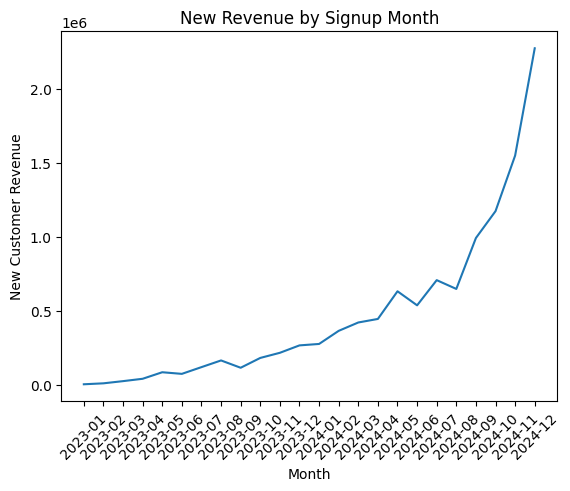

In [4]:
#New Revenue by Signup Month Visual

query_mrr = """
SELECT
  strftime('%Y-%m', start_date) AS month,
  SUM(mrr_amount) AS total_mrr
FROM subscriptions
GROUP BY month
ORDER BY month;
"""

df_mrr = pd.read_sql(query_mrr, conn)

plt.figure()
plt.plot(df_mrr['month'], df_mrr['total_mrr'])
plt.xticks(rotation=45)

plt.title("New Revenue by Signup Month")
plt.xlabel("Month")
plt.ylabel("New Customer Revenue")

plt.show()

#Revenue Growth Insights

- New customer revenue shows strong upward growth over time, increasing significantly throughout 2024
- Growth accelerates in the second half of 2024, indicating increased customer acquisition or customer expansion
- There are some fluctuations month-to-month, but the overall trend reflects rapid business growth

#Churn Analysis

This section analyzes how many customers cancel their subscriptions each month.

In [5]:
#Churn Analysis

query = """
SELECT
  strftime('%Y-%m', end_date) AS churn_month,
  COUNT(*) AS churned_customers
FROM subscriptions
WHERE churn_flag = 1
  AND end_date IS NOT NULL
GROUP BY churn_month
ORDER BY churn_month;
"""
pd.read_sql(query, conn)


,churn_month,churned_customers
0,2023-04,1
1,2023-06,1
2,2023-07,1
3,2023-08,1
4,2023-10,3
5,2023-11,8
6,2023-12,3
7,2024-01,11
8,2024-02,7
9,2024-03,9


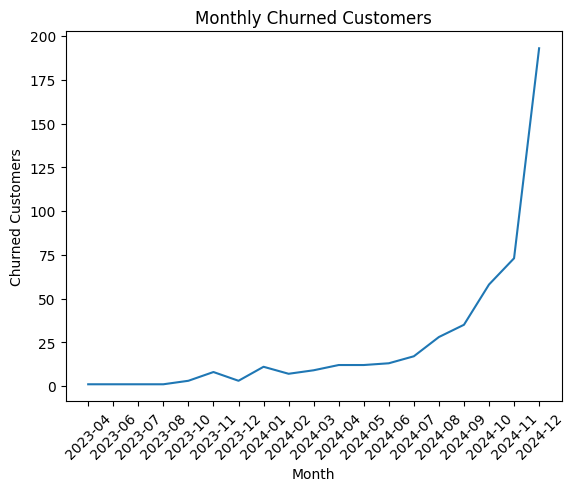

In [6]:
#Monthly Churn Trend

df_churn = pd.read_sql(query, conn)

plt.figure()
plt.plot(df_churn['churn_month'], df_churn['churned_customers'])
plt.xticks(rotation=45)
plt.title("Monthly Churned Customers")
plt.xlabel("Month")
plt.ylabel("Churned Customers")
plt.show()

#Monthly Churn Trend Insights

- Churn increases alongside growth, suggesting onboarding and customer success processes are not scaling effectively. The company should investigate onboarding experience and support capacity during high-growth periods
- The number of churned customers rises alongside overall growth, suggesting scaling challenges
- The large spike in December 2024 may indicate retention issues or seasonal behavior

In [7]:
#Active Customers Per Month

query_active = """
SELECT
  strftime('%Y-%m', start_date) AS month,
  COUNT(DISTINCT account_id) AS active_customers
FROM subscriptions
GROUP BY month
ORDER BY month;
"""
df_active = pd.read_sql(query_active, conn)
df_active

,month,active_customers
0,2023-01,2
1,2023-02,9
2,2023-03,16
3,2023-04,25
4,2023-05,26
5,2023-06,36
6,2023-07,45
7,2023-08,63
8,2023-09,51
9,2023-10,65


In [9]:
#Reuse Churn Data

query_churn = """
SELECT
  strftime('%Y-%m', start_date) AS month,
  COUNT(*) AS churned_customers
FROM subscriptions
WHERE churn_flag = 1
  AND end_date IS NOT NULL
GROUP BY month
ORDER BY month;
"""

df_churn = pd.read_sql(query_churn, conn)
df_churn

,month,churned_customers
0,2023-02,4
1,2023-03,2
2,2023-04,2
3,2023-05,5
4,2023-06,4
5,2023-07,10
6,2023-08,8
7,2023-09,14
8,2023-10,9
9,2023-11,16


## Churn Rate

Churn rate is calculated as the percentage of customers who cancel in a given month relative to total customers.

In [10]:
#Churn Rate Calculation

df_merged = pd.merge(df_active, df_churn, on='month', how='left')
df_merged['churned_customers'] = df_merged['churned_customers'].fillna(0)

df_merged["churn_rate"] = df_merged["churned_customers"] / df_merged["active_customers"]

df_merged

,month,active_customers,churned_customers,churn_rate
0,2023-01,2,0.0,0.000000
1,2023-02,9,4.0,0.444444
2,2023-03,16,2.0,0.125000
3,2023-04,25,2.0,0.080000
4,2023-05,26,5.0,0.192308
5,2023-06,36,4.0,0.111111
6,2023-07,45,10.0,0.222222
7,2023-08,63,8.0,0.126984
8,2023-09,51,14.0,0.274510
9,2023-10,65,9.0,0.138462


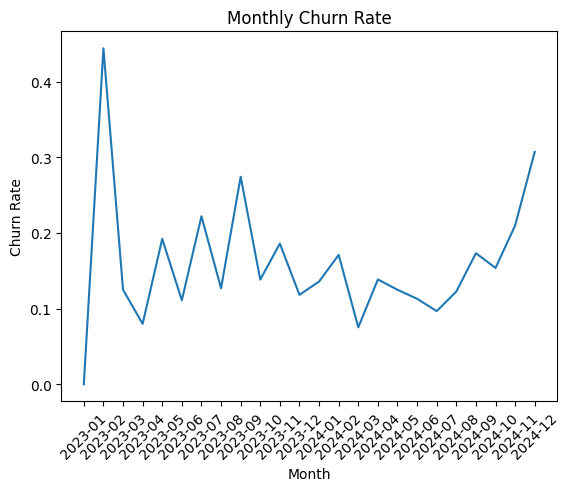

In [17]:
#Churn Rate Calculation Visual

plt.figure()
plt.plot(df_merged['month'], df_merged['churn_rate'])
plt.xticks(rotation=45)
plt.title("Monthly Churn Rate")
plt.xlabel("Month")
plt.ylabel("Churn Rate")
plt.show()

#Monthly Churn Rate Insights

- Churn rate fluctuates over time, with higher volatility in early months due to a smaller customer base
- As the customer base grows, churn rate becomes more stable but increases again in later months
- The spike in churn rate toward the end of the period suggests potential retention or product issues

In [11]:
#Churn Count by Plan


query = """
SELECT
  plan_tier,
  COUNT(*) AS churned_customers
FROM subscriptions
WHERE churn_flag = 1
GROUP BY plan_tier
ORDER BY churned_customers DESC;
"""
pd.read_sql(query, conn)

,plan_tier,churned_customers
0,Enterprise,172
1,Pro,162
2,Basic,152


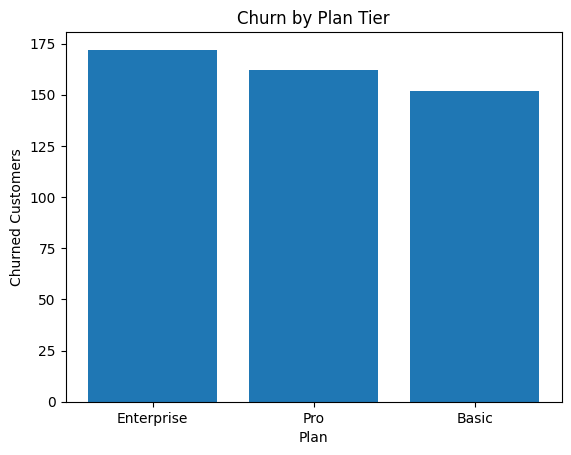

In [12]:
#Churn Count by Plan Plan Visual

df_plan_churn = pd.read_sql(query, conn)

plt.figure()
plt.bar(df_plan_churn['plan_tier'], df_plan_churn['churned_customers'])
plt.title("Churn by Plan Tier")
plt.xlabel("Plan")
plt.ylabel("Churned Customers")
plt.show()

#Churn by Tier Insights

- The Enterprise plan has the highest total churn, followed closely by Pro and Basic plans
- Higher churn in Enterprise may be due to a larger customer base or higher expectations from customers
- Differences across plans suggest varying customer behavior depending on pricing or features

## Churn by Plan

This analysis identifies which subscription plans have the highest churn.

In [13]:
#Churn Rate by Plan

query = """
SELECT
  plan_tier,
  COUNT(*) AS total_customers,
  SUM(CASE WHEN churn_flag = 1 THEN 1 ELSE 0 END) AS churned_customers,
  ROUND(
    1.0 * SUM(CASE WHEN churn_flag = 1 THEN 1 ELSE 0 END) / COUNT(*), 3) AS churn_rate
FROM subscriptions
GROUP BY plan_tier
ORDER BY churn_rate DESC;
"""
pd.read_sql(query, conn)

,plan_tier,total_customers,churned_customers,churn_rate
0,Enterprise,1723,172,0.100
1,Pro,1675,162,0.097
2,Basic,1602,152,0.095


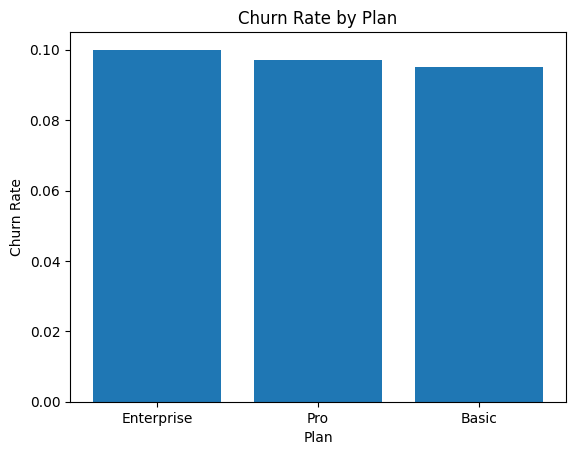

In [14]:
#Churn Rate by Plan Visual

df_plan_rate = pd.read_sql(query, conn)

plt.figure()
plt.bar(df_plan_rate['plan_tier'], df_plan_rate['churn_rate'])
plt.title("Churn Rate by Plan")
plt.xlabel("Plan")
plt.ylabel("Churn Rate")
plt.show()

#Churn Rate Insights

- The Enterprise plan has the highest churn rate, indicating relatively weaker retention compared to other plans
- Churn rates across all plans are fairly close, suggesting consistent retention challenges across tiers
- Slightly higher churn in Enterprise may indicate pricing or value expectations are not fully met

## Retention Analysis

This section analyzes how long customers stay subscribed before churning.

In [15]:
#Customer Lifetime by Plan (Monthly)

query = """
SELECT
  subscription_id,
  plan_tier,
  start_date,
  end_date,
  CASE
    WHEN end_date IS NOT NULL
    THEN (julianday(end_date) - julianday(start_date)) / 30.0
    ELSE NULL
  END AS lifetime_months
FROM subscriptions
WHERE churn_flag = 1;
"""

df_lifetime = pd.read_sql(query, conn)
df_lifetime.head()

,subscription_id,plan_tier,start_date,end_date,lifetime_months
0,S-8cec59,Enterprise,2023-12-23,2024-04-12,3.700000
1,S-f81687,Enterprise,2024-11-23,2024-12-13,0.666667
2,S-13939b,Pro,2023-07-21,2024-08-03,12.633333
3,S-9333c5,Basic,2024-06-06,2024-08-13,2.266667
4,S-3bd427,Basic,2024-12-04,2024-12-27,0.766667


In [16]:
#Average Customer Lifetime by Plan (Monthly)

query = """
SELECT
  plan_tier,
  ROUND(AVG((julianday(end_date) - julianday(start_date)) / 30.0), 2) AS avg_lifetime_months
FROM subscriptions
WHERE churn_flag = 1
GROUP BY plan_tier
ORDER BY avg_lifetime_months DESC;
"""
pd.read_sql(query, conn)

,plan_tier,avg_lifetime_months
0,Basic,3.34
1,Enterprise,2.79
2,Pro,2.72


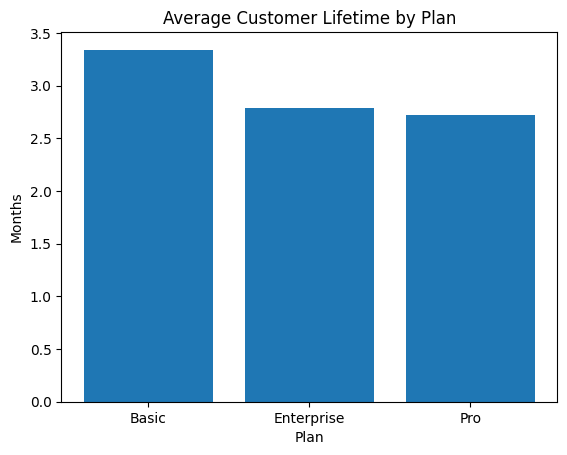

In [17]:
#Average Customer Lifetime by Plan (Monthly) Visual)

df_lifetime_tier = pd.read_sql(query, conn)

plt.figure()
plt.bar(df_lifetime_tier['plan_tier'], df_lifetime_tier['avg_lifetime_months'])
plt.title("Average Customer Lifetime by Plan")
plt.xlabel("Plan")
plt.ylabel("Months")
plt.show()

#Retention Insights

- Customers on the Basic plan have the longest average lifetime, indicating stronger retention at lower price tiers
- Enterprise and Pro plans have slightly shorter lifetimes, suggesting potential challenges in retaining higher-value customers
- Overall customer lifetime is relatively short across all plans, highlighting an opportunity to improve long-term retention

## Cohort Analysis

Cohort analysis groups customers by their signup month to evaluate retention trends over time.

This analysis groups customers by their signup month (cohort) and calculates the average lifetime of each cohort.

The goal is to understand whether customers who joined at different times behave differently in terms of retention.

In [18]:
#Cohort Analysis (Average Customer Lifetime)

query = """
SELECT
  account_id,
  plan_tier,
  strftime('%Y-%m', start_date) AS cohort_month,
  CASE
    WHEN end_date IS NOT NULL
    THEN (julianday(end_date) - julianday(start_date)) / 30.0
    ELSE (julianday('now') - julianday(start_date)) / 30.0
  END AS lifetime_months
FROM subscriptions;
"""

df_cohort = pd.read_sql(query, conn)
df_cohort.head()

,account_id,plan_tier,cohort_month,lifetime_months
0,A-3c1a3f,Enterprise,2023-12,3.700000
1,A-9b9fe9,Pro,2024-06,23.199345
2,A-659280,Enterprise,2024-11,17.632678
3,A-e7a1e2,Enterprise,2024-11,0.666667
4,A-ba6516,Enterprise,2024-01,28.299345


This table summarizes each cohort (grouped by signup month) by showing the total number of customers and their average lifetime.

It provides a high-level view of how customer retention varies across different signup periods.

In [19]:
#Cohort Summary Table

query = """
SELECT
  strftime('%Y-%m', start_date) AS cohort_month,
  COUNT(*) AS total_customers,
  ROUND(AVG(
    CASE
      WHEN end_date IS NOT NULL
      THEN (julianday(end_date) - julianday(start_date)) / 30.0
      ELSE (julianday('now') - julianday(start_date)) / 30.0
    END
  ), 2) AS avg_lifetime
FROM subscriptions
GROUP BY cohort_month
ORDER BY cohort_month;
"""

df_cohort_summary = pd.read_sql(query, conn)

print(df_cohort_summary.to_string(index=False))

cohort_month  total_customers  avg_lifetime
     2023-01                3         40.25
     2023-02               11         28.26
     2023-03               17         35.80
     2023-04               31         35.24
     2023-05               29         31.99
     2023-06               46         33.26
     2023-07               59         29.86
     2023-08               82         30.77
     2023-09               62         26.45
     2023-10               84         28.45
     2023-11              121         27.17
     2023-12              121         27.06
     2024-01              134         25.62
     2024-02              152         24.27
     2024-03              186         24.87
     2024-04              193         23.03
     2024-05              245         22.40
     2024-06              248         21.54
     2024-07              330         20.81
     2024-08              337         19.52
     2024-09              440         18.17
     2024-10              504   

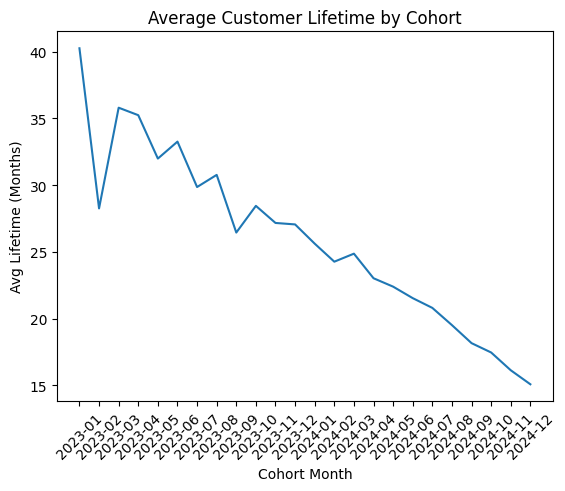

In [20]:
#Cohort Summary Visual

plt.figure()
plt.plot(df_cohort_summary['cohort_month'], df_cohort_summary['avg_lifetime'])
plt.xticks(rotation=45)
plt.title("Average Customer Lifetime by Cohort")
plt.xlabel("Cohort Month")
plt.ylabel("Avg Lifetime (Months)")
plt.show()

#Cohort Insights

- Earlier cohorts show significantly higher average lifetime compared to more recent cohorts
- Average lifetime declines over time, suggesting newer customers are not retaining as long
- This may indicate changes in customer quality, onboarding experience, or product-market fit over time

#Key Findings

- New customer revenue shows strong and accelerating growth, particularly in late 2024
- Churn increases alongside growth, indicating potential retention challenges at scale
- Churn rate stabilizes but rises again in later months, suggesting emerging issues
- Enterprise plan has the highest churn rate, pointing to possible pricing or expectation gaps
- Customer lifetime is relatively short across all plans, highlighting retention opportunities
- Cohort analysis suggests that newer customers are retaining less effectively than earlier cohorts

#Actionable Recommendations

- Improve onboarding for new customers (cohort decline)
- Investigate Enterprise churn drivers (pricing / expectations gap)
- Introduce retention campaigns before month 3 (short lifetime)
- Monitor churn spikes in Q4 (seasonality risk)